In [1]:
# Does not need to be run again, but here is the code that was used to download the data from the original source.
#
# import os
# import urllib.request

# DATA_DIR = "data"
# BASE_URL = "https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master"

# os.makedirs(DATA_DIR, exist_ok=True)

# for i in range(1, 13):
#     filename = f"IRAhandle_tweets_{i}.csv"
#     local_path = os.path.join(DATA_DIR, filename)
#     if os.path.exists(local_path):
#         print(f"already have {filename}")
#         continue
#     print(f"downloading {filename}...")
#     urllib.request.urlretrieve(f"{BASE_URL}/{filename}", local_path)

# print("done")

In [2]:
#I rewrote this logic so that we do not need to rescrape each time. 
#It should work as long as you are working in the proper directory

import pandas as pd

frames = []
for i in range(1, 13):
        frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))

df = pd.concat(frames, ignore_index=True)
df.head()

/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_62987/992374803.py:8: DtypeWarning: Columns (0,15,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_62987/992374803.py:8: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_62987/992374803.py:8: DtypeWarning: Columns (10,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))


,external_author_id,author,content,region,language,publish_date,harvested_date,following,followers,updates,...,account_type,retweet,account_category,new_june_2018,alt_external_id,tweet_id,article_url,tco1_step1,tco2_step1,tco3_step1
0,906000000000000000,10_GOP,"""We have a sitting Democrat US Senator on tria...",Unknown,English,10/1/2017 19:58,10/1/2017 19:59,1052,9636,253,...,Right,0,RightTroll,0,905874659358453760,914580356430536707,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914580356430...,NaN,NaN
1,906000000000000000,10_GOP,Marshawn Lynch arrives to game in anti-Trump s...,Unknown,English,10/1/2017 22:43,10/1/2017 22:43,1054,9637,254,...,Right,0,RightTroll,0,905874659358453760,914621840496189440,http://twitter.com/905874659358453760/statuses...,https://twitter.com/damienwoody/status/9145685...,NaN,NaN
2,906000000000000000,10_GOP,Daughter of fallen Navy Sailor delivers powerf...,Unknown,English,10/1/2017 22:50,10/1/2017 22:51,1054,9637,255,...,Right,1,RightTroll,0,905874659358453760,914623490375979008,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/913231923715...,NaN,NaN
3,906000000000000000,10_GOP,JUST IN: President Trump dedicates Presidents ...,Unknown,English,10/1/2017 23:52,10/1/2017 23:52,1062,9642,256,...,Right,0,RightTroll,0,905874659358453760,914639143690555392,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914639143690...,NaN,NaN
4,906000000000000000,10_GOP,"19,000 RESPECTING our National Anthem! #StandF...",Unknown,English,10/1/2017 2:13,10/1/2017 2:13,1050,9645,246,...,Right,1,RightTroll,0,905874659358453760,914312219952861184,http://twitter.com/905874659358453760/statuses...,https://twitter.com/realDonaldTrump/status/914...,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
 15  alt_external_id     object
 16  tweet_id            int64 
 17  article_url         object
 18  tco1_step1          object
 19  tco2_step1          object
 20  tco3_step1          object
dtypes: int64(6), object(15)
memory usage: 468.7+ MB


In [4]:
cleaned_df = df.drop(columns=["tweet_id", "alt_external_id", "article_url", "tco1_step1", "tco2_step1", "tco3_step1"])

In [5]:
cleaned_df["post_type"].head()

0        NaN
1        NaN
2    RETWEET
3        NaN
4    RETWEET
Name: post_type, dtype: object

In [6]:
cleaned_df["post_type"].groupby(cleaned_df["post_type"]).count()

post_type
QUOTE_TWEET      39938
RETWEET        1239753
Name: post_type, dtype: int64

In [7]:
cleaned_df["region"].groupby(cleaned_df["region"]).count()

region
Afghanistan                     3318
Austria                            1
Azerbaijan                     94916
Belarus                        27335
Canada                           608
Czech Republic                     7
Denmark                            1
Egypt                            232
Estonia                            1
Finland                           20
France                           942
Germany                        27178
Greece                            81
Hong Kong                          3
India                             22
Iran, Islamic Republic of        541
Iraq                           11117
Israel                          3604
Italy                          13474
Japan                            108
Latvia                             7
Malaysia                        4932
Mexico                            41
Russian Federation             37052
Samoa                             32
Saudi Arabia                      55
Serbia                         

In [8]:
cleaned_df.replace({"post_type": {None: "TWEET"}}, inplace=True)

In [9]:
cleaned_df["post_type"].head()

0      TWEET
1      TWEET
2    RETWEET
3      TWEET
4    RETWEET
Name: post_type, dtype: object

In [10]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [11]:
cleaned_df["external_author_id"] = cleaned_df["external_author_id"].astype(str) 
cleaned_df["author"] = cleaned_df["author"].astype(str) 
cleaned_df["content"] = cleaned_df["content"].astype(str) 
cleaned_df["region"] = cleaned_df["region"].astype(str)
cleaned_df["language"] = cleaned_df["language"].astype(str)
cleaned_df["account_category"] = cleaned_df["account_category"].astype(str)

In [12]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [13]:
# cleaned_df["publish_date"] = pd.to_datetime(cleaned_df["publish_date"], format="mixed", errors="coerce")
# min_date = cleaned_df["publish_date"].min()
# max_date = cleaned_df["publish_date"].max()
# cleaned_df["publish_date"] = -1 + 2 * (cleaned_df["publish_date"] - min_date) / (max_date - min_date)
# cleaned_df["publish_date"].describe()

In [14]:
#New method for date

cleaned_df["publish_date"] = pd.to_datetime(cleaned_df["publish_date"], format="mixed", errors="coerce")
min_date = cleaned_df["publish_date"].min()
max_date = cleaned_df["publish_date"].max()
election_date = pd.to_datetime("2016-11-08")

cleaned_df["publish_date"] = cleaned_df["publish_date"].apply(
    lambda x: (x - election_date) / (election_date - min_date) if x < election_date
              else (x - election_date) / (max_date - election_date)
)
cleaned_df["publish_date"].describe()

count    2.925313e+06
mean     2.417267e-02
std      2.623759e-01
min     -1.000000e+00
25%     -1.933239e-01
50%     -3.044669e-02
75%      2.091662e-01
max      1.000000e+00
Name: publish_date, dtype: float64

In [15]:
count = (cleaned_df["publish_date"] >= 0).astype(int)
count.value_counts()

publish_date
0    1689047
1    1236266
Name: count, dtype: int64

In [16]:
import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sia.polarity_scores("TRUMP 2020!!! Make America Great Again!")

{'neg': 0.0, 'neu': 0.487, 'pos': 0.513, 'compound': 0.7405}

In [17]:
import re

english_df = cleaned_df[cleaned_df["language"] == "English"].copy()
english_df = english_df.sample(frac=0.25, random_state=67).copy()

_rt_prefix = re.compile(r"^RT @\w+:\s*")
_url = re.compile(r"https?://\S+|www\.\S+")

def clean_tweet(text):
    text = _rt_prefix.sub("", text)
    text = _url.sub("", text)
    return text.strip()

english_df["content_clean"] = english_df["content"].map(clean_tweet)
print(f"English tweets (25% sample): {len(english_df):,}")
english_df[["content", "content_clean"]].head()

English tweets (25% sample): 526,316


,content,content_clean
420191,"Who sets my course, Determines my values, My r...","Who sets my course, Determines my values, My r..."
1495424,#news Legislation limiting who could serve on ...,#news Legislation limiting who could serve on ...
2326526,Appeal hearing for NFL's Brady begins in New Y...,Appeal hearing for NFL's Brady begins in New Y...
710825,Woman dies after being hit by a truck in Torra...,Woman dies after being hit by a truck in Torrance
662267,Al Franked must resign immediately #ResignAl h...,Al Franked must resign immediately #ResignAl


In [18]:
from tqdm.auto import tqdm
tqdm.pandas(desc="VADER")

scores = english_df["content_clean"].progress_map(sia.polarity_scores)
scores_df = pd.DataFrame(scores.tolist(), index=english_df.index)
scores_df.columns = ["sent_neg", "sent_neu", "sent_pos", "sent_compound"]

english_df = pd.concat([english_df, scores_df], axis=1)
english_df[["content_clean", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head()

VADER:   0%|          | 0/526316 [00:00<?, ?it/s]

,content_clean,sent_neg,sent_neu,sent_pos,sent_compound
420191,"Who sets my course, Determines my values, My r...",0.180,0.640,0.18,0.0000
1495424,#news Legislation limiting who could serve on ...,0.203,0.797,0.00,-0.4215
2326526,Appeal hearing for NFL's Brady begins in New Y...,0.000,1.000,0.00,0.0000
710825,Woman dies after being hit by a truck in Torrance,0.000,1.000,0.00,0.0000
662267,Al Franked must resign immediately #ResignAl,0.324,0.676,0.00,-0.3400


In [19]:
english_df["sent_compound"].describe()

count    526316.000000
mean         -0.039634
std           0.418344
min          -0.994500
25%          -0.340000
50%           0.000000
75%           0.202300
max           0.999100
Name: sent_compound, dtype: float64

In [20]:
english_df.groupby("account_category")["sent_compound"].agg(["mean", "std", "count"]).sort_values("mean")

,mean,std,count
account_category,,,
NewsFeed,-0.119473,0.391177,149081
RightTroll,-0.052576,0.444997,174869
Fearmonger,-0.024555,0.435855,2664
LeftTroll,0.025090,0.437267,104158
HashtagGamer,0.030042,0.366983,58838
NonEnglish,0.035640,0.410415,6520
Commercial,0.050344,0.319425,28385
Unknown,0.093317,0.429255,1801


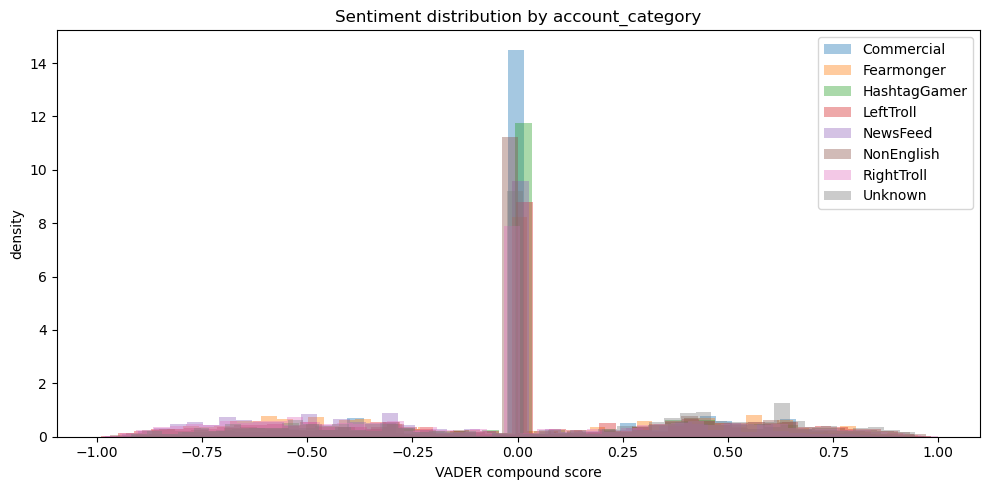

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in english_df.groupby("account_category"):
    grp["sent_compound"].plot(kind="hist", bins=50, alpha=0.4, label=cat, ax=ax, density=True)
ax.set_xlabel("VADER compound score")
ax.set_ylabel("density")
ax.set_title("Sentiment distribution by account_category")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
for cat in english_df["account_category"].unique():
    sub = english_df[english_df["account_category"] == cat]
    print(f"\n=== {cat} ===")
    print("most positive:", sub.loc[sub["sent_compound"].idxmax(), "content_clean"][:140])
    print("most negative:", sub.loc[sub["sent_compound"].idxmin(), "content_clean"][:140])


=== LeftTroll ===
most positive: A goal &amp; an assist but most important is a great win by the team ✌ congrats to peterborough and good luck for the season�#cfc #jobdone
most negative: stop the war stop the war stop the war stop the war stop the war stop the war #EndYemenWar they don't know no love

=== NewsFeed ===
most positive: FORECAST \| Terrific Weather Tuesday!: More bright, beautiful sunshine and pleasant temperatur...  #Cleveland #news
most negative: Cleveland rapist pleads guilty to another rape and murder of Michaela Diemer: A convicted rapist pleaded guilty Tuesday to the...  #crime

=== RightTroll ===
most positive: We win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we w
most negative: Kill, kill, kill, kill, kill, kill  #America

=== HashtagGamer ===
most positive: Happy Sunday Sweet Friends  It's a Gorgeous Day, Life is Wonderful .. Enjoy Every Moment! Love & Happiness 2 All �
most ne

In [ ]:
features_df = english_df[[
    "author",
    "publish_date",
    "following",
    "followers",
    "updates",
    "post_type",
    "account_type",
    "retweet",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound",
    "account_category",
]].copy()

features_df.head()

,author,publish_date,following,followers,updates,post_type,account_type,retweet,sent_neg,sent_neu,sent_pos,sent_compound,account_category
420191,BRIANTHELIFTER,0.197165,520,836,3744,RETWEET,Left,1,0.180,0.640,0.18,0.0000,LeftTroll
1495424,KANSASDAILYNEWS,-0.187762,6952,22358,25426,TWEET,local,0,0.203,0.797,0.00,-0.4215,NewsFeed
2326526,ROOMOFRUMOR,-0.289151,6025,11908,3597,TWEET,news,0,0.000,1.000,0.00,0.0000,NewsFeed
710825,DAILYLOSANGELES,0.202071,6308,17906,11851,TWEET,local,0,0.000,1.000,0.00,0.0000,NewsFeed
662267,COVFEFENATIONUS,0.657862,248,2223,148186,RETWEET,Right,1,0.324,0.676,0.00,-0.3400,RightTroll


In [ ]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526316 entries, 420191 to 511535
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   author            526316 non-null  object 
 1   publish_date      526316 non-null  float64
 2   following         526316 non-null  int64  
 3   followers         526316 non-null  int64  
 4   updates           526316 non-null  int64  
 5   post_type         526316 non-null  object 
 6   account_type      526316 non-null  object 
 7   retweet           526316 non-null  int64  
 8   sent_neg          526316 non-null  float64
 9   sent_neu          526316 non-null  float64
 10  sent_pos          526316 non-null  float64
 11  sent_compound     526316 non-null  float64
 12  account_category  526316 non-null  object 
dtypes: float64(5), int64(4), object(4)
memory usage: 56.2+ MB


In [ ]:
#Flawed split?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

y = (features_df["publish_date"] >= 0).astype(int)
X = features_df.drop(columns=["publish_date", "author"])
X = pd.get_dummies(X, columns=["post_type", "account_type", "account_category"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.9826
              precision    recall  f1-score   support

           0     0.9859    0.9824    0.9841     57962
           1     0.9785    0.9827    0.9806     47302

    accuracy                         0.9826    105264
   macro avg     0.9822    0.9826    0.9824    105264
weighted avg     0.9826    0.9826    0.9826    105264



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

y = (features_df["publish_date"] >= 0).astype(int)
X = features_df.drop(columns=["publish_date", "author"])
X = pd.get_dummies(X, columns=["post_type", "account_type", "account_category"])

groups = features_df["author"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.8220
              precision    recall  f1-score   support

           0     0.8368    0.8263    0.8315     65945
           1     0.8056    0.8171    0.8113     58099

    accuracy                         0.8220    124044
   macro avg     0.8212    0.8217    0.8214    124044
weighted avg     0.8222    0.8220    0.8221    124044

